# Módulo 3 — Programación Dinámica para Rebalanceo de Portafolio## Proyecto Semana 14 · ADA · UNMSM**Algoritmo:** Backward Induction de Bellman (ecuación de DP discreta)**Referencia:** Vaezi Jezeie et al. (2022). PLoS ONE 17(8), e0271811.**Inspirado en:** Eq5 Notebook B + Eq1 Notebook DP

In [11]:
!pip install yfinance --quiet

In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
import json
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
TICKERS = ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']
FECHA_INICIO, FECHA_FIN = '2015-01-01', '2024-12-31'
CAPITAL, DIAS_ANIO, RF = 100_000, 252, 0.02

# Parámetros DP
LAMBDA_TC = 0.001   # Costo de transacción (0.1%)
T_PERIODOS = 12     # Número de periodos de rebalanceo
PASO_GRILLA = 0.20  # Paso de discretización de pesos (20%) - Adjusted to speed up computation

datos = yf.download(TICKERS, start=FECHA_INICIO, end=FECHA_FIN, auto_adjust=True, progress=False)
precios = datos['Close'].dropna(how='all').dropna()

if isinstance(precios.columns, pd.MultiIndex):
    precios.columns = precios.columns.get_level_values(0)

retornos = np.log(precios / precios.shift(1)).dropna()
mu_vec = retornos.mean().values * DIAS_ANIO
Sigma = retornos.cov().values * DIAS_ANIO
N = len(TICKERS)

print(f"Parámetros DP: λ_TC={LAMBDA_TC}, T={T_PERIODOS}, paso={PASO_GRILLA}")

Parámetros DP: λ_TC=0.001, T=12, paso=0.2


## 1. Discretización del espacio de estados y funciones de costo

In [13]:
from scipy.optimize import minimize

# Portafolio objetivo (mínima varianza)
res = minimize(lambda w: np.sqrt(w@Sigma@w), np.ones(N)/N, method='SLSQP',
               bounds=[(0,1)]*N, constraints={'type':'eq','fun':lambda w:w.sum()-1})
w_objetivo = res.x

# Generar grilla de pesos discretizados
from itertools import product

pasos = np.arange(0, 1 + PASO_GRILLA/2, PASO_GRILLA)
grilla = []
for combo in product(pasos, repeat=N):
    if abs(sum(combo) - 1.0) < 1e-6:
        grilla.append(np.array(combo))

grilla = np.array(grilla)
G = len(grilla)
print(f"Grilla generada: {G} estados factibles (N={N}, paso={PASO_GRILLA})")

def costo_transaccion(w_actual, w_nuevo):
    return LAMBDA_TC * np.sum(np.abs(w_nuevo - w_actual))

def costo_suboptimalidad(w):
    return np.sqrt((w - w_objetivo) @ Sigma @ (w - w_objetivo))

def idx_mas_cercano(w):
    dists = np.linalg.norm(grilla - w, axis=1)
    return int(np.argmin(dists))

Grilla generada: 126 estados factibles (N=5, paso=0.2)


## 2. Backward Induction — Ecuación de Bellman

In [14]:
# Simular retornos por periodo
dias_por_periodo = len(retornos) // T_PERIODOS
retornos_periodo = []
for t in range(T_PERIODOS):
    ini = t * dias_por_periodo
    fin = min((t+1) * dias_por_periodo, len(retornos))
    r_acum = retornos.iloc[ini:fin].sum().values
    retornos_periodo.append(r_acum)

# Tablas DP
J_star = np.full((T_PERIODOS + 1, G), 0.0)  # Costo óptimo
politica = np.full((T_PERIODOS, G), -1, dtype=int)  # Acción óptima

# Backward induction: t = T-1 hasta t = 0
print("Ejecutando backward induction...")
for t in range(T_PERIODOS - 1, -1, -1):
    for s in range(G):
        w_actual = grilla[s]
        mejor_costo = float('inf')
        mejor_accion = s  # No rebalancear por defecto
        for a in range(G):
            w_nuevo = grilla[a]
            tc = costo_transaccion(w_actual, w_nuevo)
            eps = costo_suboptimalidad(w_nuevo)
            # Evolucionar pesos con retornos del periodo
            w_evol = w_nuevo * np.exp(retornos_periodo[t])
            w_evol = w_evol / w_evol.sum()
            s_next = idx_mas_cercano(w_evol)
            costo_total = tc + eps + J_star[t+1, s_next]
            if costo_total < mejor_costo:
                mejor_costo = costo_total
                mejor_accion = a
        J_star[t, s] = mejor_costo
        politica[t, s] = mejor_accion
    if t % 4 == 0:
        print(f"  Periodo t={t}: costo óptimo medio = {J_star[t].mean():.6f}")
print("Backward induction completada.")

Ejecutando backward induction...
  Periodo t=8: costo óptimo medio = 0.159826
  Periodo t=4: costo óptimo medio = 0.318940
  Periodo t=0: costo óptimo medio = 0.478455
Backward induction completada.


## 3. Reconstrucción forward y simulación de 3 estrategias

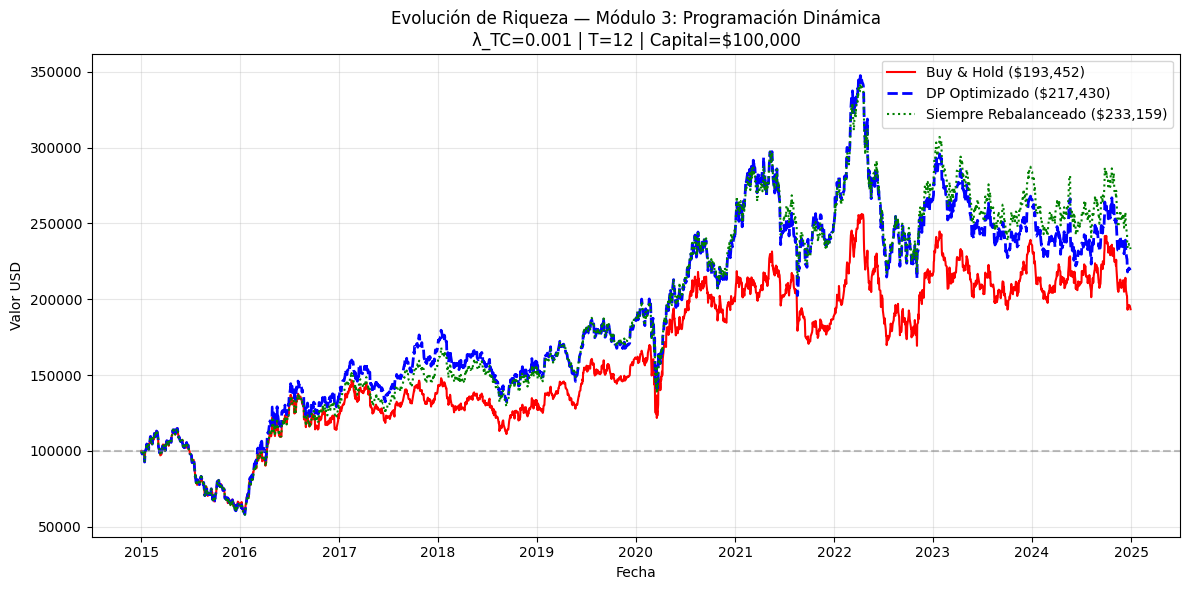

════════════════════════════════════════════════════════════
Estrategia                          Riqueza     Costos  Rebal
────────────────────────────────────────────────────────────
Buy & Hold                     $   193,452 $       0      0
DP Optimizado                  $   217,430 $     414     11
Siempre Rebalanceado           $   233,159 $     421     12

Resultados guardados en resultados_m3.json


In [15]:
ret_simples = precios.pct_change().dropna()

def simular_estrategia(nombre, w_init, rebalancear_fn):
    riqueza = [CAPITAL]
    w_t = w_init.copy()
    costos = 0
    n_reb = 0
    for i in range(len(ret_simples)):
        r = ret_simples.iloc[i].values
        riqueza.append(riqueza[-1] * (1 + w_t @ r))
        # Decidir rebalanceo cada inicio de periodo
        if i > 0 and i % dias_por_periodo == 0:
            w_nuevo = rebalancear_fn(w_t, i // dias_por_periodo)
            if not np.allclose(w_nuevo, w_t, atol=0.01):
                costos += costo_transaccion(w_t, w_nuevo) * riqueza[-1]
                n_reb += 1
            w_t = w_nuevo.copy()
        else:
            w_t = w_t * (1 + r)
            w_t /= w_t.sum()
    return riqueza, costos, n_reb

# Estrategia 1: Buy & Hold
riq_bh, _, _ = simular_estrategia('BH', w_objetivo, lambda w, t: w)

# Estrategia 2: DP Optimizado
s0 = idx_mas_cercano(w_objetivo)
def dp_rebalanceo(w_t, t_periodo):
    if t_periodo < T_PERIODOS:
        s = idx_mas_cercano(w_t)
        return grilla[politica[t_periodo, s]]
    return w_t
riq_dp, costos_dp, n_reb_dp = simular_estrategia('DP', w_objetivo, dp_rebalanceo)

# Estrategia 3: Siempre Rebalanceado
riq_sr, costos_sr, n_reb_sr = simular_estrategia('SR', w_objetivo, lambda w, t: w_objetivo)

fechas = [precios.index[0]] + list(ret_simples.index)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(fechas, riq_bh, 'r-', lw=1.5, label=f'Buy & Hold (${riq_bh[-1]:,.0f})')
ax.plot(fechas, riq_dp, 'b--', lw=2, label=f'DP Optimizado (${riq_dp[-1]:,.0f})')
ax.plot(fechas, riq_sr, 'g:', lw=1.5, label=f'Siempre Rebalanceado (${riq_sr[-1]:,.0f})')
ax.axhline(y=CAPITAL, color='gray', ls='--', alpha=0.5)
ax.set_title(f'Evolución de Riqueza — Módulo 3: Programación Dinámica\nλ_TC={LAMBDA_TC} | T={T_PERIODOS} | Capital=${CAPITAL:,.0f}')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor USD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("═" * 60)
print(f"{'Estrategia':<30s} {'Riqueza':>12s} {'Costos':>10s} {'Rebal':>6s}")
print("─" * 60)
for nom, riq, cos, nr in [('Buy & Hold', riq_bh, 0, 0),
                            ('DP Optimizado', riq_dp, costos_dp, n_reb_dp),
                            ('Siempre Rebalanceado', riq_sr, costos_sr, n_reb_sr)]:
    print(f"{nom:<30s} ${riq[-1]:>10,.0f} ${cos:>8,.0f} {nr:>6d}")

resultados_m3 = {'riqueza_bh': float(riq_bh[-1]), 'riqueza_dp': float(riq_dp[-1]),
                 'riqueza_sr': float(riq_sr[-1]), 'costos_dp': float(costos_dp)}
with open('resultados_m3.json', 'w') as f:
    json.dump(resultados_m3, f, indent=2)
print("\nResultados guardados en resultados_m3.json")

## 4. Heatmap de la tabla DP (costos óptimos)

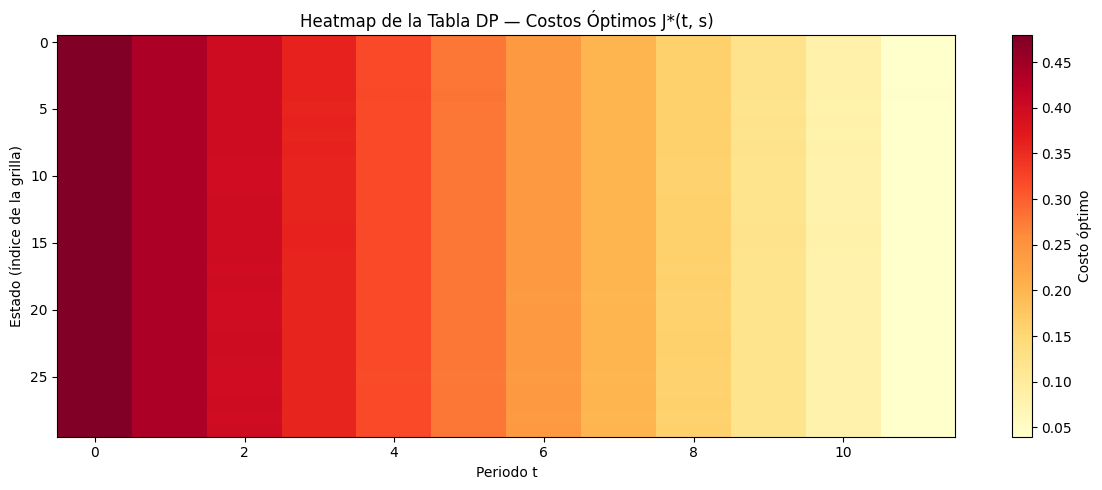

Referencia: Vaezi Jezeie et al. (2022). PLoS ONE 17(8), e0271811. DOI: 10.1371/journal.pone.0271811


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
# Seleccionar subconjunto de estados para visualización
n_show = min(30, G)
indices = np.linspace(0, G-1, n_show, dtype=int)
im = ax.imshow(J_star[:T_PERIODOS, indices].T, aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Periodo t')
ax.set_ylabel('Estado (índice de la grilla)')
ax.set_title('Heatmap de la Tabla DP — Costos Óptimos J*(t, s)')
plt.colorbar(im, ax=ax, label='Costo óptimo')
plt.tight_layout()
plt.show()
print(f"Referencia: Vaezi Jezeie et al. (2022). PLoS ONE 17(8), e0271811. DOI: 10.1371/journal.pone.0271811")